<a href="https://colab.research.google.com/github/AMitra13/rfm-customer-segmentation/blob/main/RFM_Segmentation_Project_Polished.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Customer RFM Segmentation & Cohort Analysis**

**Dataset**: UCI Online Retail (sourced from [UCI ML Repository](https://archive.ics.uci.edu/ml/datasets/online+retail))  
**Tools**: Python, pandas, NumPy, Matplotlib, Seaborn, SQLite  
**Author**: Ayshi  

---

## Project Overview

This project analyzes e-commerce transaction data to understand customer purchasing behavior and identify high-value customer segments using RFM (Recency, Frequency, Monetary) analysis.

The analysis reveals that a small percentage of customers generate a large portion of revenue. By identifying loyal and at-risk customers, businesses can design targeted marketing strategies to improve retention and maximize revenue.

## Business Questions

1. Who are the most valuable customers?
2. Which customers are at risk of churn?
3. What percentage of revenue comes from top customers?
4. How often do customers make purchases?
5. Which countries generate the most revenue?

---

## Requirements

```
pandas
numpy
matplotlib
seaborn
```

# **1. Setup & Imports**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

# Plot styling
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100

# **2. ETL — Extract, Transform, Load**

## 2.1 Extract — Load the Dataset

In [ ]:
# Load the dataset
# Dataset: UCI Online Retail - https://archive.ics.uci.edu/ml/datasets/online+retail
from google.colab import files
uploaded = files.upload()
df = pd.read_csv("OnlineRetail.csv", encoding="latin1")

#print(f"Shape: {df.shape}")
#df.head()

Saving OnlineRetail.csv to OnlineRetail.csv


In [ ]:
# Check structure — data types and missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


## 2.2 Transform — Data Cleaning

In [ ]:
# Remove rows with missing CustomerID (cannot segment without it)
df = df.dropna(subset=["CustomerID"])
print(f"Shape after dropping null CustomerIDs: {df.shape}")

Shape after dropping null CustomerIDs: (406829, 8)


In [ ]:
# Remove cancelled orders (InvoiceNo starting with 'C')
df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]
print(f"Shape after removing cancellations: {df.shape}")

Shape after removing cancellations: (397924, 8)


In [ ]:
# Remove negative or zero quantities
df = df[df["Quantity"] > 0]
print(f"Shape after removing invalid quantities: {df.shape}")

Shape after removing invalid quantities: (397924, 8)


In [ ]:
# Convert InvoiceDate to datetime
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
print(f"Date range: {df['InvoiceDate'].min().date()} to {df['InvoiceDate'].max().date()}")

Date range: 2010-12-01 to 2011-12-09


In [ ]:
# Create Revenue column
df["Revenue"] = df["Quantity"] * df["UnitPrice"]
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


## 2.3 Load — Save Cleaned Dataset

In [ ]:
# Save cleaned dataset
df.to_csv("clean_retail_data.csv", index=False)
print("Cleaned dataset saved to clean_retail_data.csv")

Cleaned dataset saved to clean_retail_data.csv


# **3. Exploratory Data Analysis**

## 3.1 Revenue by Country

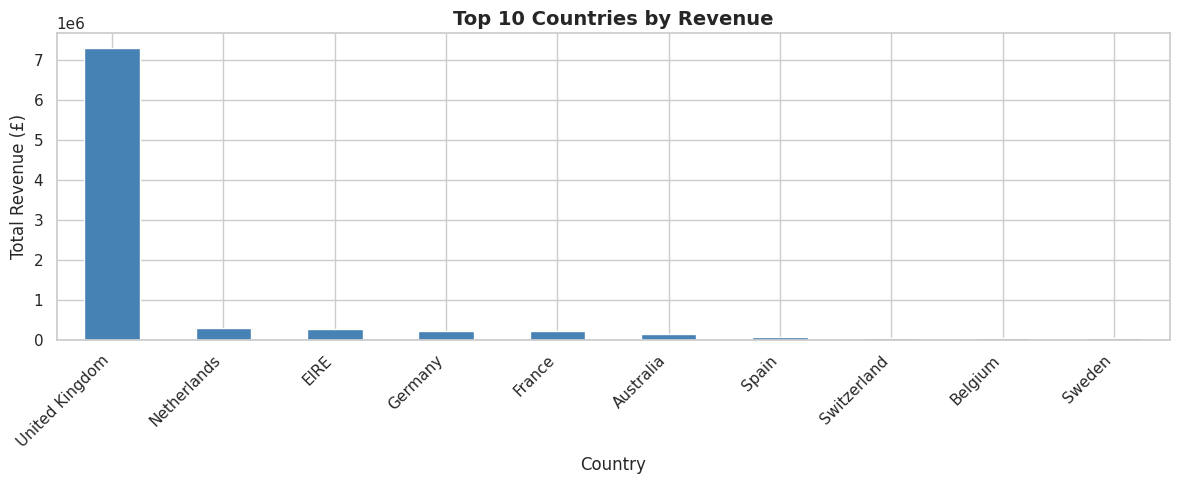

,Country,Total Revenue (£)
0,United Kingdom,7308391.554
1,Netherlands,285446.340
2,EIRE,265545.900
3,Germany,228867.140
4,France,209024.050
5,Australia,138521.310
6,Spain,61577.110
7,Switzerland,56443.950
8,Belgium,41196.340
9,Sweden,38378.330


In [ ]:
# Revenue by Country (top 10)
country_sales = df.groupby("Country")["Revenue"].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
country_sales.head(10).plot(kind="bar", ax=ax, color="steelblue", edgecolor="white")
ax.set_title("Top 10 Countries by Revenue", fontsize=14, fontweight="bold")
ax.set_xlabel("Country", fontsize=12)
ax.set_ylabel("Total Revenue (£)", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

display(country_sales.head(10).reset_index().rename(columns={"Revenue": "Total Revenue (£)"}))

## 3.2 Monthly Revenue Trend

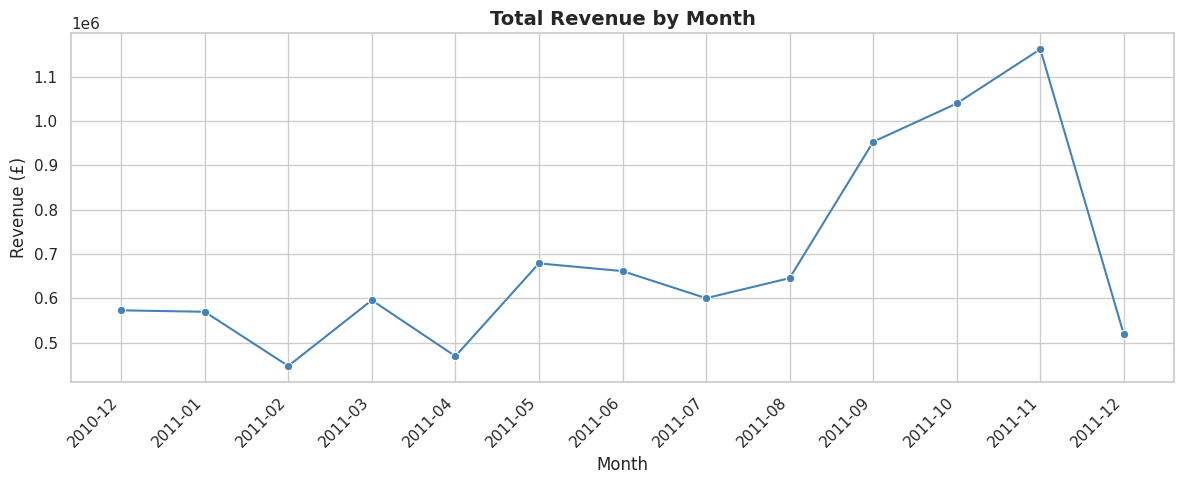

,InvoiceMonth,Revenue
0,2010-12,572713.890
1,2011-01,569445.040
2,2011-02,447137.350
3,2011-03,595500.760
4,2011-04,469200.361
5,2011-05,678594.560
6,2011-06,661213.690
7,2011-07,600091.011
8,2011-08,645343.900
9,2011-09,952838.382


In [ ]:
# Monthly Revenue Trend
df["InvoiceMonth"] = df["InvoiceDate"].dt.to_period("M")
monthly_revenue = df.groupby("InvoiceMonth")["Revenue"].sum().reset_index()
monthly_revenue["InvoiceMonth"] = monthly_revenue["InvoiceMonth"].astype(str)

fig, ax = plt.subplots(figsize=(12, 5))
sns.lineplot(x="InvoiceMonth", y="Revenue", data=monthly_revenue, marker="o", ax=ax, color="steelblue")
ax.set_title("Total Revenue by Month", fontsize=14, fontweight="bold")
ax.set_xlabel("Month", fontsize=12)
ax.set_ylabel("Revenue (£)", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

display(monthly_revenue)

## 3.3 Top Products by Revenue

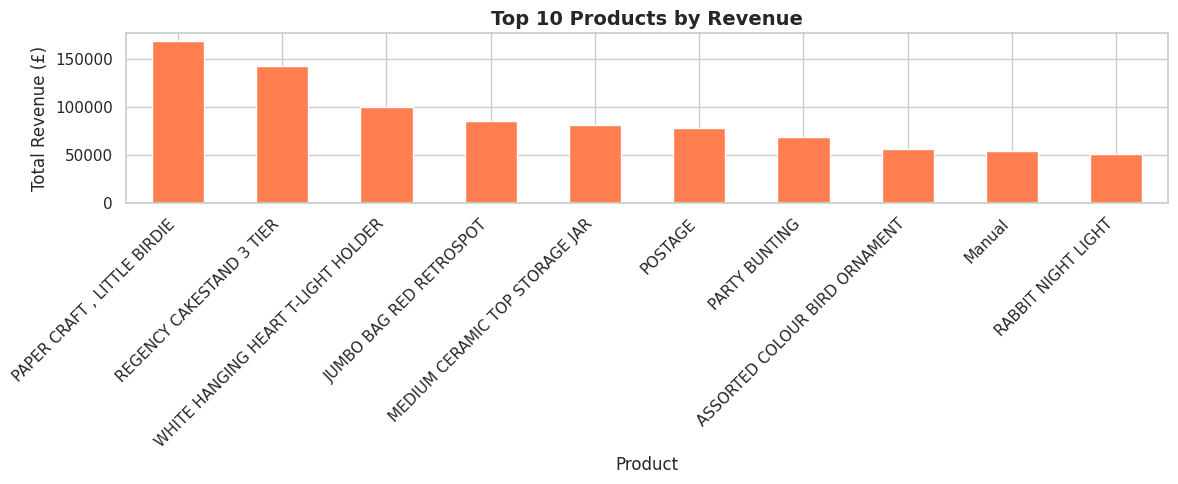

In [ ]:
# Top 10 Products by Revenue
top_products = df.groupby("Description")["Revenue"].sum().sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(12, 5))
top_products.plot(kind="bar", ax=ax, color="coral", edgecolor="white")
ax.set_title("Top 10 Products by Revenue", fontsize=14, fontweight="bold")
ax.set_xlabel("Product", fontsize=12)
ax.set_ylabel("Total Revenue (£)", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# **4. SQL Analysis**

In [ ]:
# Load cleaned data into SQLite for SQL-based analysis
if "InvoiceMonth" in df.columns:
    df["InvoiceMonth"] = df["InvoiceMonth"].astype(str)

conn = sqlite3.connect("retail.db")
df.to_sql("sales", conn, index=False, if_exists="replace")
print("SQLite database created and data loaded successfully.")

SQLite database created and data loaded successfully.


In [ ]:
# Total Revenue
query = """
SELECT ROUND(SUM(Revenue), 2) AS total_revenue
FROM sales
"""
pd.read_sql(query, conn)

,total_revenue
0,8911407.9


In [ ]:
# Top 10 Customers by Revenue
query = """
SELECT CustomerID, ROUND(SUM(Revenue), 2) AS total_revenue
FROM sales
GROUP BY CustomerID
ORDER BY total_revenue DESC
LIMIT 10
"""
pd.read_sql(query, conn)

,CustomerID,total_revenue
0,14646.0,280206.02
1,18102.0,259657.30
2,17450.0,194550.79
3,16446.0,168472.50
4,14911.0,143825.06
5,12415.0,124914.53
6,14156.0,117379.63
7,17511.0,91062.38
8,16029.0,81024.84
9,12346.0,77183.60


In [ ]:
# Revenue by Country
query = """
SELECT Country, ROUND(SUM(Revenue), 2) AS revenue
FROM sales
GROUP BY Country
ORDER BY revenue DESC
"""
pd.read_sql(query, conn)

,Country,revenue
0,United Kingdom,7308391.55
1,Netherlands,285446.34
2,EIRE,265545.90
3,Germany,228867.14
4,France,209024.05
5,Australia,138521.31
6,Spain,61577.11
7,Switzerland,56443.95
8,Belgium,41196.34
9,Sweden,38378.33


# **5. RFM Segmentation**

## 5.1 Build RFM Table

**RFM** measures three dimensions of customer behaviour:
- **Recency (R)**: Days since last purchase — lower is better
- **Frequency (F)**: Number of transactions — higher is better  
- **Monetary (M)**: Total spend — higher is better

In [ ]:
# Snapshot date: one day after the last invoice
snapshot_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)
print(f"Snapshot date: {snapshot_date.date()}")

Snapshot date: 2011-12-10


In [ ]:
# Aggregate RFM metrics per customer
rfm = df.groupby("CustomerID").agg(
    Recency=("InvoiceDate", lambda x: (snapshot_date - x.max()).days),
    Frequency=("InvoiceNo", "count"),
    Monetary=("Revenue", "sum")
)

print(f"Customers: {len(rfm):,}")
rfm.describe().round(2)

Customers: 4,339


,Recency,Frequency,Monetary
count,4339.00,4339.00,4339.00
mean,92.52,91.71,2053.79
std,100.01,228.79,8988.25
min,1.00,1.00,0.00
25%,18.00,17.00,307.24
50%,51.00,41.00,674.45
75%,142.00,100.00,1661.64
max,374.00,7847.00,280206.02


## 5.2 Score & Segment Customers

In [ ]:
# RFM Scoring using quantiles (1-4 scale)
# Recency: lower days = better = higher score (labels reversed)
# Frequency & Monetary: higher = better = higher score
rfm["R"] = pd.qcut(rfm["Recency"], 4, labels=[4, 3, 2, 1])
rfm["F"] = pd.qcut(rfm["Frequency"].rank(method="first"), 4, labels=[1, 2, 3, 4])
rfm["M"] = pd.qcut(rfm["Monetary"], 4, labels=[1, 2, 3, 4])

# Combine into a single score string
rfm["RFM_Score"] = rfm["R"].astype(str) + rfm["F"].astype(str) + rfm["M"].astype(str)

# Numeric total score for threshold-based segmentation
rfm["RFM_Total"] = rfm["R"].astype(int) + rfm["F"].astype(int) + rfm["M"].astype(int)

rfm.head()

,Recency,Frequency,Monetary,R,F,M,RFM_Score,RFM_Total
CustomerID,,,,,,,,
12346.0,326,1,77183.60,1,1,4,114,6
12347.0,2,182,4310.00,4,4,4,444,12
12348.0,75,31,1797.24,2,2,4,224,8
12349.0,19,73,1757.55,3,3,4,334,10
12350.0,310,17,334.40,1,1,2,112,4


In [ ]:
# Customer Segmentation based on RFM scores
def segment_customer(row):
    r, f, m = int(row["R"]), int(row["F"]), int(row["M"])
    rfm_total = row["RFM_Total"]

    if r >= 3 and f >= 3 and m >= 3:
        return "Champions"
    elif f >= 3 and rfm_total >= 9:
        return "Loyal Customers"
    elif r >= 3 and f <= 2:
        return "Promising"
    elif r <= 2 and f >= 3:
        return "At Risk"        # Was active, now gone quiet
    elif r <= 2 and rfm_total <= 6:
        return "Lost"           # Low recency AND low overall score
    else:
        return "Others"         # Mid-range customers, no clear pattern

rfm["Segment"] = rfm.apply(segment_customer, axis=1)

segment_counts = rfm["Segment"].value_counts()
print("Segment Distribution:")
display(segment_counts)

Segment Distribution:


,count
Segment,
Lost,1356
Champions,1299
Promising,690
At Risk,454
Loyal Customers,307
Others,233


In [ ]:
# Profile each segment to understand who's in it
# Reset the index to make CustomerID a column for aggregation
rfm = rfm.reset_index()

segment_profile = rfm.groupby("Segment").agg(
    Count=("CustomerID", "count"),
    Avg_R=("R", lambda x: x.astype(int).mean()),
    Avg_F=("F", lambda x: x.astype(int).mean()),
    Avg_M=("M", lambda x: x.astype(int).mean()),
    Avg_RFM_Total=("RFM_Total", "mean"),
    Avg_Recency_Days=("Recency", "mean"),
    Avg_Frequency=("Frequency", "mean"),
    Avg_Monetary=("Monetary", "mean")
).round(2)

display(segment_profile)

,Count,Avg_R,Avg_F,Avg_M,Avg_RFM_Total,Avg_Recency_Days,Avg_Frequency,Avg_Monetary
Segment,,,,,,,,
At Risk,454,1.57,3.09,2.50,7.16,146.83,69.23,873.51
Champions,1299,3.60,3.64,3.62,10.86,17.26,215.62,4936.10
Lost,1356,1.37,1.42,1.55,4.34,191.85,16.15,462.82
Loyal Customers,307,2.44,3.68,3.26,9.38,68.80,130.17,2083.80
Others,233,2.51,2.41,2.51,7.42,61.10,44.44,997.02
Promising,690,3.40,1.59,1.90,6.89,24.41,20.55,874.24


In [ ]:
# See how many customers are at each RFM_Total score
print(rfm.groupby("RFM_Total").size().reset_index(name="Count"))
print()

# Cross R score vs RFM_Total
print(pd.crosstab(rfm["R"].astype(int), rfm["RFM_Total"], margins=True))

   RFM_Total  Count
0          3    375
1          4    383
2          5    521
3          6    461
4          7    458
5          8    456
6          9    417
7         10    429
8         11    390
9         12    449

RFM_Total    3    4    5    6    7    8    9   10   11   12   All
R                                                                
1          375  207  271   95   80   35   21    0    0    0  1084
2            0  176  131  210  156  198   94  101    0    0  1066
3            0    0  119   88  172  121  206  140  217    0  1063
4            0    0    0   68   50  102   96  188  173  449  1126
All        375  383  521  461  458  456  417  429  390  449  4339


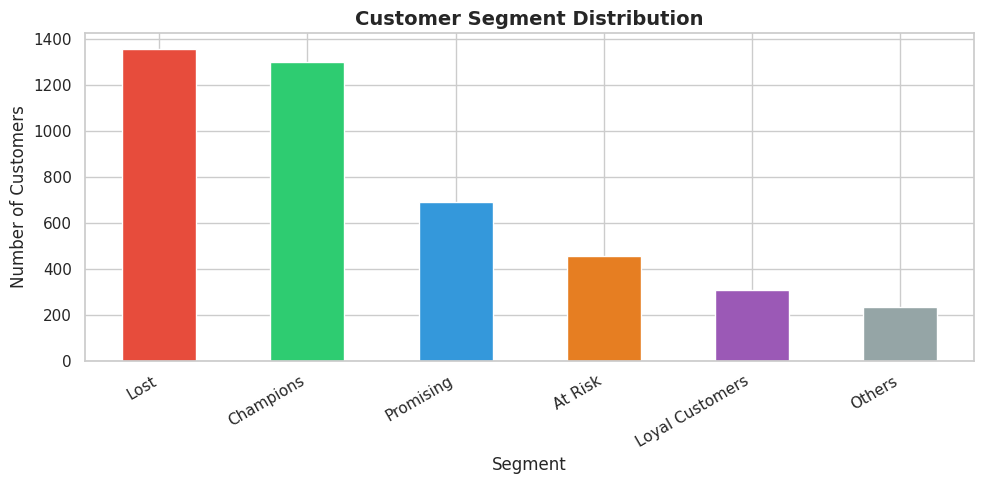

In [ ]:
# Visualize Segment Distribution
fig, ax = plt.subplots(figsize=(10, 5))
colors = ["#e74c3c", "#2ecc71", "#3498db", "#e67e22", "#9b59b6", "#95a5a6"]
segment_counts.plot(kind="bar", ax=ax, color=colors[:len(segment_counts)], edgecolor="white")
ax.set_title("Customer Segment Distribution", fontsize=14, fontweight="bold")
ax.set_xlabel("Segment", fontsize=12)
ax.set_ylabel("Number of Customers", fontsize=12)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## 5.3 Enrich RFM with Country

In [ ]:
# Map each customer to their primary country
customer_country = df.groupby("CustomerID")["Country"].first().reset_index()

rfm = rfm.reset_index()
rfm = rfm.merge(customer_country, on="CustomerID", how="left")

print(f"RFM table shape: {rfm.shape}")
rfm.head()

RFM table shape: (4339, 12)


,index,CustomerID,Recency,Frequency,Monetary,R,F,M,RFM_Score,RFM_Total,Segment,Country
0,0,12346.0,326,1,77183.60,1,1,4,114,6,Lost,United Kingdom
1,1,12347.0,2,182,4310.00,4,4,4,444,12,Champions,Iceland
2,2,12348.0,75,31,1797.24,2,2,4,224,8,Others,Finland
3,3,12349.0,19,73,1757.55,3,3,4,334,10,Champions,Italy
4,4,12350.0,310,17,334.40,1,1,2,112,4,Lost,Norway


In [ ]:
# Export RFM segmentation results
rfm.to_csv("rfm_segmentation.csv", index=False)
print("Saved: rfm_segmentation.csv")

Saved: rfm_segmentation.csv


# **6. Pareto Analysis (80/20 Rule)**

In [ ]:
# Pareto Analysis: what % of customers drive 80% of revenue?
customer_revenue = df.groupby("CustomerID")["Revenue"].sum().sort_values(ascending=False)

pareto_df = customer_revenue.reset_index()
pareto_df.columns = ["CustomerID", "Revenue"]
pareto_df["CumulativeRevenue"] = pareto_df["Revenue"].cumsum()
total_revenue = pareto_df["Revenue"].sum()
pareto_df["CumulativePercent"] = pareto_df["CumulativeRevenue"] / total_revenue

# Find the cutoff: how many customers make up 80% of revenue
top_80_cutoff = (pareto_df["CumulativePercent"] <= 0.8).sum()
pct_customers = top_80_cutoff / len(pareto_df) * 100
print(f"Top {pct_customers:.1f}% of customers generate 80% of revenue ({top_80_cutoff:,} customers)")

Top 26.1% of customers generate 80% of revenue (1,132 customers)


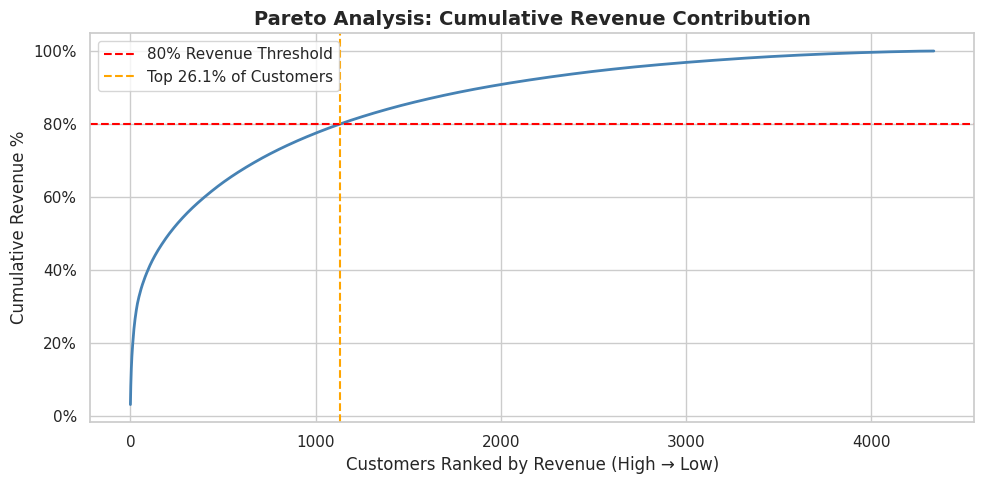

In [ ]:
# Pareto Curve
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(len(pareto_df)), pareto_df["CumulativePercent"], color="steelblue", linewidth=2)
ax.axhline(0.8, color="red", linestyle="--", label="80% Revenue Threshold")
ax.axvline(top_80_cutoff, color="orange", linestyle="--", label=f"Top {pct_customers:.1f}% of Customers")
ax.set_title("Pareto Analysis: Cumulative Revenue Contribution", fontsize=14, fontweight="bold")
ax.set_xlabel("Customers Ranked by Revenue (High → Low)", fontsize=12)
ax.set_ylabel("Cumulative Revenue %", fontsize=12)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
ax.legend()
plt.tight_layout()
plt.show()

# **7. Customer Lifetime Value (CLV)**

CLV is estimated using the formula:

> **CLV = AOV × Purchase Frequency × Customer Lifespan (years)**

Where:
- **AOV** = Average Order Value = Total Revenue / Total Orders
- **Purchase Frequency** = Total orders per customer
- **Lifespan** = Days between first and last purchase, converted to years

In [ ]:
# Calculate AOV and order counts per customer
customer_metrics = df.groupby("CustomerID").agg(
    TotalOrders=("InvoiceNo", "nunique"),
    TotalRevenue=("Revenue", "sum")
)

customer_metrics["AOV"] = customer_metrics["TotalRevenue"] / customer_metrics["TotalOrders"]
customer_metrics["PurchaseFrequency"] = customer_metrics["TotalOrders"]

# Calculate customer lifespan (first to last purchase)
customer_lifespan = df.groupby("CustomerID").agg(
    FirstPurchase=("InvoiceDate", "min"),
    LastPurchase=("InvoiceDate", "max")
)
customer_lifespan["LifespanDays"] = (customer_lifespan["LastPurchase"] - customer_lifespan["FirstPurchase"]).dt.days
customer_lifespan["LifespanYears"] = customer_lifespan["LifespanDays"] / 365

# Merge and calculate CLV
customer_metrics = customer_metrics.merge(customer_lifespan["LifespanYears"], left_index=True, right_index=True)
customer_metrics["CLV"] = customer_metrics["AOV"] * customer_metrics["PurchaseFrequency"] * customer_metrics["LifespanYears"]

customer_metrics.describe().round(2)

,TotalOrders,TotalRevenue,AOV,PurchaseFrequency,LifespanYears,CLV
count,4339.00,4339.00,4339.00,4339.00,4339.00,4339.00
mean,4.27,2053.79,419.05,4.27,0.36,1467.74
std,7.71,8988.25,1796.32,7.71,0.36,8399.29
min,1.00,0.00,0.00,1.00,0.00,0.00
25%,1.00,307.24,178.50,1.00,0.00,0.00
50%,2.00,674.45,293.69,2.00,0.25,162.61
75%,5.00,1661.64,430.02,5.00,0.69,938.69
max,210.00,280206.02,84236.25,210.00,1.02,270993.77


In [ ]:
# Merge CLV into RFM table (drop any prior AOV/CLV columns to avoid duplicates)
cols_to_drop = [col for col in rfm.columns if "AOV" in col or "CLV" in col]
rfm = rfm.drop(columns=cols_to_drop)

rfm = rfm.merge(customer_metrics[["AOV", "CLV"]], left_on="CustomerID", right_index=True)
print(f"RFM table shape after CLV merge: {rfm.shape}")
rfm.head()

RFM table shape after CLV merge: (4339, 14)


,index,CustomerID,Recency,Frequency,Monetary,R,F,M,RFM_Score,RFM_Total,Segment,Country,AOV,CLV
0,0,12346.0,326,1,77183.60,1,1,4,114,6,Lost,United Kingdom,77183.600000,0.000000
1,1,12347.0,2,182,4310.00,4,4,4,444,12,Champions,Iceland,615.714286,4310.000000
2,2,12348.0,75,31,1797.24,2,2,4,224,8,Others,Finland,449.310000,1388.552548
3,3,12349.0,19,73,1757.55,3,3,4,334,10,Champions,Italy,1757.550000,0.000000
4,4,12350.0,310,17,334.40,1,1,2,112,4,Lost,Norway,334.400000,0.000000


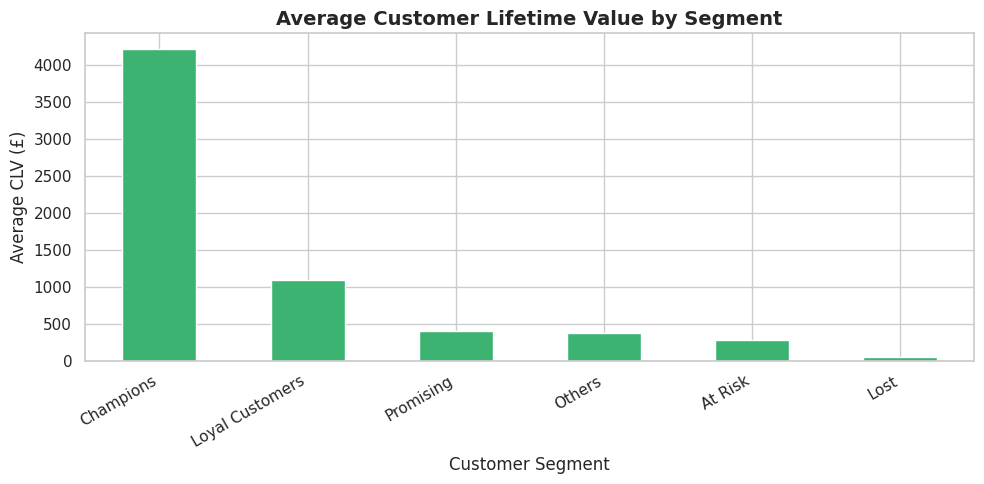

,CLV
Segment,
Champions,4215.35
Loyal Customers,1092.85
Promising,399.12
Others,366.82
At Risk,280.46
Lost,50.94


In [ ]:
# Average CLV by Segment
clv_by_segment = rfm.groupby("Segment")["CLV"].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
clv_by_segment.plot(kind="bar", ax=ax, color="mediumseagreen", edgecolor="white")
ax.set_title("Average Customer Lifetime Value by Segment", fontsize=14, fontweight="bold")
ax.set_xlabel("Customer Segment", fontsize=12)
ax.set_ylabel("Average CLV (£)", fontsize=12)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

display(clv_by_segment.round(2))

# **8. Customer Cohort Analysis**

Cohort analysis tracks how groups of customers (defined by their first purchase month) behave over time. The retention rate shows what % of each cohort returned in subsequent months.

In [ ]:
# Assign invoice month and cohort month (first purchase month per customer)
df["InvoiceMonth"] = df["InvoiceDate"].dt.to_period("M")
df["CohortMonth"] = df.groupby("CustomerID")["InvoiceMonth"].transform("min")

# Convert to timestamps for arithmetic
df["InvoiceMonth_ts"] = df["InvoiceMonth"].dt.to_timestamp()
df["CohortMonth_ts"] = df["CohortMonth"].dt.to_timestamp()

# Cohort index = months since first purchase
df["CohortIndex"] = (
    (df["InvoiceMonth_ts"].dt.year - df["CohortMonth_ts"].dt.year) * 12 +
    (df["InvoiceMonth_ts"].dt.month - df["CohortMonth_ts"].dt.month)
)

print("Cohort index range:", df["CohortIndex"].min(), "to", df["CohortIndex"].max())

Cohort index range: 0 to 12


In [ ]:
# Build cohort retention table
cohort_data = df.groupby(["CohortMonth", "CohortIndex"])["CustomerID"].nunique().reset_index()
cohort_table = cohort_data.pivot(index="CohortMonth", columns="CohortIndex", values="CustomerID")

# Convert to retention rates (divide each row by cohort size at index 0)
cohort_size = cohort_table.iloc[:, 0]
retention_table = cohort_table.divide(cohort_size, axis=0)

print(f"Cohort table shape: {retention_table.shape}")

Cohort table shape: (13, 13)


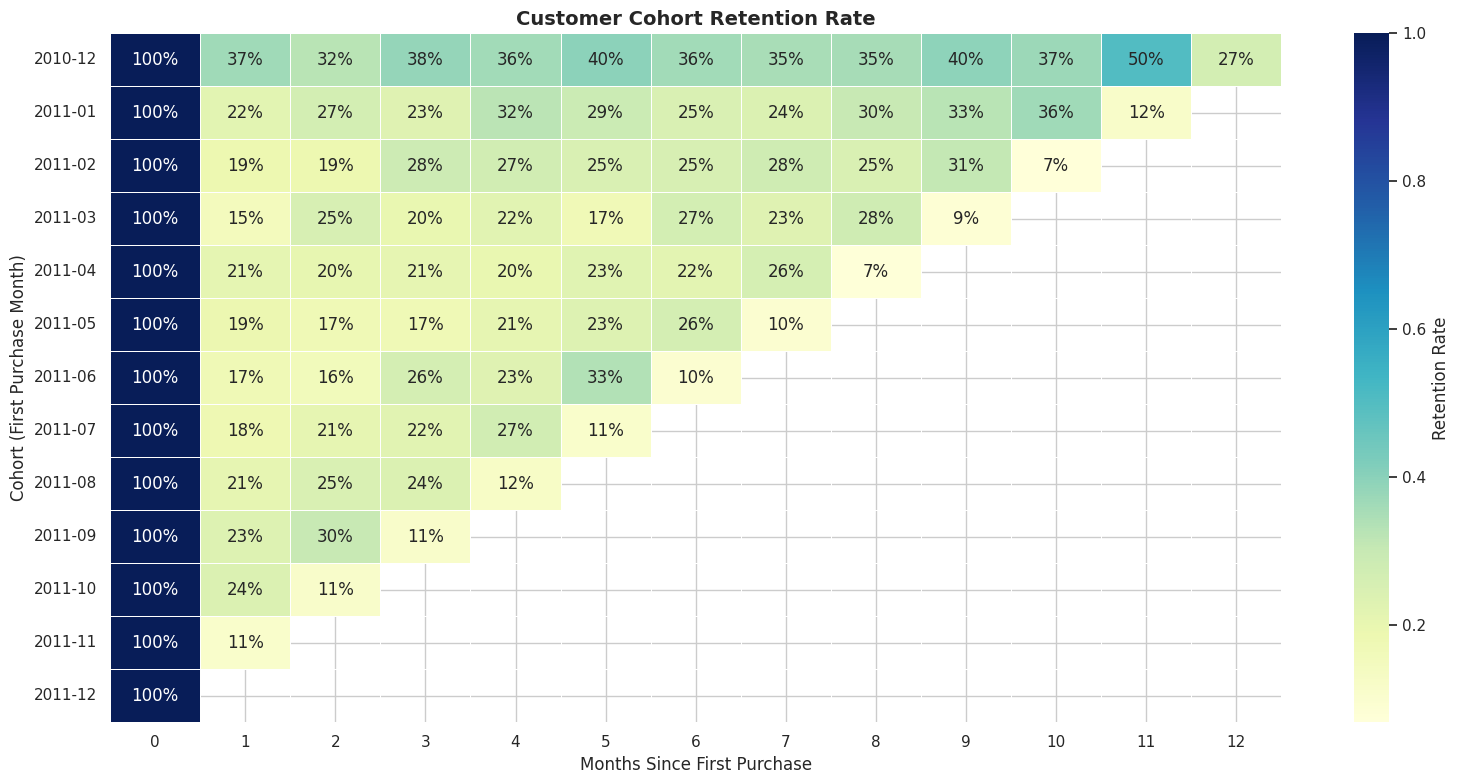

In [ ]:
# Cohort Retention Heatmap
fig, ax = plt.subplots(figsize=(16, 8))
sns.heatmap(
    retention_table,
    annot=True,
    fmt=".0%",
    cmap="YlGnBu",
    linewidths=0.5,
    ax=ax,
    cbar_kws={"label": "Retention Rate"}
)
ax.set_title("Customer Cohort Retention Rate", fontsize=14, fontweight="bold")
ax.set_xlabel("Months Since First Purchase", fontsize=12)
ax.set_ylabel("Cohort (First Purchase Month)", fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
# Save cohort retention data
retention_table.to_csv("cohort_retention_data.csv", index=True)
print("Saved: cohort_retention_data.csv")

Saved: cohort_retention_data.csv


# **9. Final Dataset Export**

In [ ]:
# Final enriched RFM dataset with rank and cumulative revenue
rfm_final = rfm.copy()
rfm_final["CustomerRank"] = rfm_final["Monetary"].rank(method="first", ascending=False)
rfm_final = rfm_final.sort_values("CustomerRank")
rfm_final["CumulativeRevenue"] = rfm_final["Monetary"].cumsum()
total_revenue = rfm_final["Monetary"].sum()
rfm_final["CumulativePercent"] = rfm_final["CumulativeRevenue"] / total_revenue

rfm_final.to_csv("rfm_final_dataset.csv", index=False)
print("Saved: rfm_final_dataset.csv")
print(f"Final dataset shape: {rfm_final.shape}")
rfm_final.head(10)

Saved: rfm_final_dataset.csv
Final dataset shape: (4339, 17)


,index,CustomerID,Recency,Frequency,Monetary,R,F,M,RFM_Score,RFM_Total,Segment,Country,AOV,CLV,CustomerRank,CumulativeRevenue,CumulativePercent
1690,1690,14646.0,2,2080,280206.02,4,4,4,444,12,Champions,Netherlands,3786.567838,270993.767288,1.0,280206.02,0.031444
4202,4202,18102.0,1,431,259657.30,4,4,4,444,12,Champions,United Kingdom,4327.621667,260368.689863,2.0,539863.32,0.060581
3729,3729,17450.0,8,337,194550.79,4,4,4,444,12,Champions,United Kingdom,4229.365000,191352.694822,3.0,734414.11,0.082413
3009,3009,16446.0,1,3,168472.50,4,1,4,414,9,Promising,United Kingdom,84236.250000,94159.972603,4.0,902886.61,0.101318
1880,1880,14911.0,1,5677,143825.06,4,4,4,444,12,Champions,EIRE,715.547562,146583.348822,5.0,1046711.67,0.117457
55,55,12415.0,24,716,124914.53,3,4,4,344,11,Champions,Australia,5948.310952,107118.487370,6.0,1171626.20,0.131475
1334,1334,14156.0,10,1400,117379.63,4,4,4,444,12,Champions,EIRE,2134.175091,116093.277890,7.0,1289005.83,0.144647
3772,3772,17511.0,3,963,91062.38,4,4,4,444,12,Champions,United Kingdom,2937.496129,92309.809863,8.0,1380068.21,0.154865
2703,2703,16029.0,39,242,81024.84,3,4,4,344,11,Champions,United Kingdom,1286.108571,74365.264110,9.0,1461093.05,0.163958
0,0,12346.0,326,1,77183.60,1,1,4,114,6,Lost,United Kingdom,77183.600000,0.000000,10.0,1538276.65,0.172619


# **10. Summary & Key Insights**

| Analysis | Key Finding |
|---|---|
| **Pareto** | A small % of customers drive ~80% of revenue |
| **RFM Segments** | Champions and Loyal Customers are the highest-value groups |
| **CLV** | Champions have significantly higher average CLV |
| **Cohort Retention** | Retention drops steeply after Month 0 — re-engagement campaigns recommended |
| **Geography** | UK dominates revenue; top 5 countries worth targeting individually |

## Recommendations

- **Champions**: Reward with loyalty programs and early access
- **Loyal Customers**: Upsell and cross-sell higher-margin products  
- **At Risk**: Trigger win-back campaigns with personalised offers
- **Lost**: Evaluate cost-effectiveness of re-engagement vs. acquisition

## Final Conclusion

- Champions are the primary revenue drivers
- Customer retention is more valuable than acquisition
- Early lifecycle engagement is critical
- RFM segmentation provides actionable business insights